# ĐỒ ÁN: DỰ ĐOÁN CHẤT LƯỢNG KHÔNG KHÍ TẠI VIỆT NAM VÀ CẢNH BÁO SỨC KHỎE
**Nhóm sinh viên:** Nhóm 11  
**Bộ dữ liệu:** Dữ liệu Chất lượng không khí & Khí tượng tại Hà Nội, TP.HCM, Đà Nẵng 

---

## Mục lục
- [1. Giới thiệu bài toán & Phương pháp thu thập dữ liệu](#1)
  - [1.1 Giới thiệu bài toán](#1-1)
  - [1.2 Nguồn dữ liệu & Tổ chức thư mục](#1-2)
- [2. Làm sạch và Tiền xử lý dữ liệu bước đầu](#2)
  - [2.1 Load & Mô tả Dataset](#2-1)
  - [2.2 Thống kê mô tả](#2-2)
  - [2.3 Xử lý Missing Values & Trùng lặp](#2-3)
- [3. Phân tích Khám phá Dữ liệu (EDA)](#3)
  - [3.1 Phân bố biến mục tiêu (AQI & Phân lớp AQI)](#3-1)
  - [3.2 Phân tích tương quan & Đa cộng tuyến (Multicollinearity)](#3-2)
  - [3.3 Phát hiện ngoại lệ (Outliers)](#3-3)
- [4. Tiền xử lý dữ liệu cho Mô hình Học máy](#4)
  - [4.1 Feature Engineering & Encode Categorical](#4-1)
  - [4.2 Train/Val/Test Split (Time-Series Split)](#4-2)
  - [4.3 Chuẩn hóa (Scaling)](#4-3)

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os

from utils import *
warnings.filterwarnings('ignore')

# Cấu hình biểu đồ
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = '../data/processed/all_cities.csv'
print('Import thư viện thành công!')

Import thư viện thành công!


---

<a id='1'></a>
## 1. Giới thiệu bài toán & Phương pháp thu thập dữ liệu

<a id='1-1'></a>
### 1.1 Giới thiệu bài toán
Ô nhiễm không khí đang là vấn đề nghiêm trọng tại các đô thị lớn. Đề tài hướng tới việc xây dựng mô hình học máy giải quyết đồng thời hai bài toán:
1. **Hồi quy (Regression):** Dự đoán giá trị AQI cụ thể trong 24-48 giờ tới.
2. **Phân lớp (Classification):** Xác định mức chất lượng không khí (Tốt / Trung bình / Kém / Xấu / Nguy hại) để đưa ra cảnh báo sức khỏe.

<a id='1-2'></a>
### 1.2 Nguồn dữ liệu & Tổ chức thư mục
Dữ liệu được thu thập từ 2 nguồn chính:
* **[Open-Meteo Air Quality API](https://open-meteo.com/en/docs/air-quality-api) (air-quality-api):** Dữ liệu lịch sử chất lượng không khí (PM2.5, PM10, O3, NO2, SO2, CO).
* **[Open-Meteo Historical Weather API](https://open-meteo.com/en/docs/historical-weather-api) (archive-api):** Dữ liệu khí tượng theo giờ (nhiệt độ, độ ẩm, gió, mưa).

**Tổ chức thư mục:** Cấu trúc lưu trữ tuân thủ chuẩn quy trình:
* `data/raw/`: Chứa các file thu thập thô riêng rẽ cho từng thành phố (Vd: `airquality_hanoi.csv`, `weather_hanoi.csv`).
* `data/processed/`: Chứa dữ liệu đã được merge theo thời gian cho từng thành phố (`merged_hanoi.csv`,...) và file hợp nhất cuối cùng `all_cities.csv`.

---

<a id='2'></a>
## 2. Làm sạch và Tiền xử lý dữ liệu bước đầu

<a id='2-1'></a>
### 2.1 Load & Mô tả Dataset
**Dataset:** Thông tin thổng hợp về chất lượng không khí và khí tượng thu thập được từ các thành phố Hà Nội, TP.HCM, Đà Nẵng theo từng giờ, từ ngày 05-08-2022 đến 29-04-2026.

| STT | Feature | Kiểu dữ liệu | Mô tả |
|---|---|---|---|
| 1 | `datetime` | object | Thời gian (định dạng yyyy-MM-dd HH:mm:ss) |
| 2 | `pm25` | float64 | Nồng độ bụi mịn PM2.5 (µg/m³) |
| 3 | `pm10` | float64 | Nồng độ bụi PM10 (µg/m³) |
| 4 | `o3` | float64 | Nồng độ khí Ozon (µg/m³) |
| 5 | `no2` | float64 | Nồng độ khí Nitơ dioxit (µg/m³) |
| 6 | `so2` | float64 | Nồng độ khí Lưu huỳnh dioxit (µg/m³) |
| 7 | `co` | float64 | Nồng độ khí Carbon monoxide (µg/m³) |
| 8 | `eu_aqi` | float64 | Chỉ số AQI theo tiêu chuẩn Cơ quan Môi trường Châu Âu (EEA) |
| 9 | `aqi` | float64 | Chỉ số AQI theo tiêu chuẩn US EPA<br>**(biến mục tiêu bài toán hồi quy)** |
| 10 | `city` | object | Tên thành phố quan trắc (Hà Nội / TP.HCM / Đà Nẵng) |
| 11 | `temp` | float64 | Nhiệt độ không khí (°C) |
| 12 | `humidity` | float64 | Độ ẩm không khí (%) |
| 13 | `wind_speed` | float64 | Tốc độ gió (m/s) |
| 14 | `wind_dir` | float64 | Hướng gió (độ, 0–360) |
| 15 | `precip` | float64 | Lượng mưa (mm) |
| 16 | `pressure` | float64 | Áp suất khí quyển (hPa) |
| 17 | `cloud_cover` | float64 | Độ che phủ mây (%) |
| 18 - 21 | `year`<br>`month`<br>`day`<br>`hour` | int64 | Thời gian quan trắc (năm, tháng, ngày, giờ) |
| 22 | `day_of_week` | int64 | Thứ trong tuần (0 = Thứ Hai, 6 = Chủ Nhật) |
| 23 | `is_weekend` | int64 | Biến nhị phân (1: Cuối tuần, 0: Ngày thường) |
| 24 | `day_of_year` | int64 | Ngày thứ trong năm (1–365/366) |
| 25 | `season` | object | Mùa (Xuân / Hạ / Thu / Đông) |
| 26 - 30 | `pm25_lag_1h`<br>`pm25_lag_3h`<br>`pm25_lag_6h`<br>`pm25_lag_12h`<br>`pm25_lag_24h` | float64 | Nồng độ PM2.5 tại các thời điểm 1h/3h/6h/12h/24h trước đó |
| 31 - 33 | `pm25_roll_6h`<br>`pm25_roll_24h`<br>`pm25_roll_72h` | float64 | Trung bình cộng nồng độ PM2.5 trong 6h/24h/72h qua |
| 34 | `aqi_category` | object | Phân loại mức chất lượng không khí (Tốt / Trung bình / Kém / Xấu / Rất xấu)<br>**(biến mục tiêu bài toán phân loại)** |


Tiến hành đọc file `all_cities.csv` từ thư mục `data/processed/`.

In [78]:
df = load_data(DATA_PATH)

# Chuyển đổi cột datetime sang định dạng chuẩn của Pandas
df['datetime'] = pd.to_datetime(df['datetime'])

print(f"Kích thước bộ dữ liệu: {df.shape}")
display(df.head())

  Dataset loaded: ../data/processed/all_cities.csv
  Số mẫu (rows)     : 98,187
  Số features (cols): 34

  Kiểu dữ liệu:
    datetime                            object      
    pm25                                float64     
    pm10                                float64     
    o3                                  float64     
    no2                                 float64     
    so2                                 float64     
    co                                  float64     
    eu_aqi                              float64     
    aqi                                 float64     
    city                                object      
    temp                                float64     
    humidity                            float64     
    wind_speed                          float64     
    wind_dir                            float64     
    precip                              float64     
    pressure                            float64     
    cloud_cover               

,datetime,pm25,pm10,o3,no2,so2,co,eu_aqi,aqi,city,...,season,pm25_lag_1h,pm25_lag_3h,pm25_lag_6h,pm25_lag_12h,pm25_lag_24h,pm25_roll_6h,pm25_roll_24h,pm25_roll_72h,aqi_category
0,2022-08-05 07:00:00,20.3,29.0,44.0,17.30,8.10,345.0,72.503334,112.822914,Hà Nội,...,Hạ,NaN,NaN,NaN,NaN,NaN,20.299999,20.299999,20.299999,Kém
1,2022-08-05 08:00:00,17.2,24.7,54.0,17.95,9.70,372.0,71.836670,110.739586,Hà Nội,...,Hạ,20.3,NaN,NaN,NaN,NaN,18.750000,18.750000,18.750000,Kém
2,2022-08-05 09:00:00,17.8,25.5,68.0,18.85,11.95,410.0,71.409996,109.406260,Hà Nội,...,Hạ,17.2,NaN,NaN,NaN,NaN,18.433333,18.433333,18.433333,Kém
3,2022-08-05 10:00:00,20.4,29.1,87.0,20.00,14.70,456.0,70.913330,107.854164,Hà Nội,...,Hạ,17.8,20.3,NaN,NaN,NaN,18.925000,18.925000,18.925000,Kém
4,2022-08-05 11:00:00,22.2,31.8,98.0,20.40,15.85,476.0,70.430000,106.343760,Hà Nội,...,Hạ,20.4,17.2,NaN,NaN,NaN,19.580000,19.580000,19.580000,Kém


<a id='2-2'></a>
### 2.2 Thống kê mô tả

Đánh giá các thống kê cơ bản: mean, median, variance, min/max, IQR, skewness và kurtosis cho các biến số.

In [79]:
numerical_cols = ['pm25', 'pm10', 'o3', 'no2', 'so2', 'co', 'temp', 'humidity', 'wind_speed', 'aqi']
describe_stats(df[numerical_cols])

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
pm25,98187.0,30.095,21.868,0.300,16.000,23.900,36.800,232.800,2.256,7.345
pm10,98187.0,39.606,26.474,0.400,22.100,32.800,48.350,291.500,2.102,6.654
o3,98187.0,78.262,54.102,-1.000,38.000,70.000,108.000,418.000,1.113,1.897
no2,98187.0,21.375,19.650,0.000,6.150,15.200,31.300,170.350,1.503,2.828
so2,98187.0,17.249,13.964,0.000,5.400,14.800,25.200,104.600,1.105,1.420
co,98187.0,565.584,426.423,59.000,307.000,449.000,674.000,5784.000,3.049,15.288
temp,98187.0,25.967,4.413,6.500,23.900,26.150,28.650,41.150,-0.512,0.952
humidity,98187.0,79.664,14.205,21.568,71.454,83.098,90.959,100.000,-0.971,0.429
wind_speed,98187.0,8.864,5.134,0.000,5.082,7.989,11.755,60.716,1.134,2.674
aqi,98187.0,93.506,39.858,12.059,63.599,83.078,115.135,284.492,0.987,0.599


**Nhận xét:**
- `pm25`, `pm10` và `co` có skewness cao (>2), phân phối lệch phải mạnh.
- `o3` có giá trị âm, không logic theo mô tả của feature này.

<a id='2-3'></a>
### 2.3 Xử lý Missing Values & Trùng lặp (Duplicates)
* Kiểm tra số lượng dòng trùng lặp do lỗi thu thập từ API.
* Xử lí giá trị âm trong `o3`
* Đánh giá tỷ lệ dữ liệu thiếu ở các cảm biến đo chất lượng không khí (PM2.5, PM10,...) và khí tượng.


In [80]:
# 1. Kiểm tra trùng lặp
duplicates = df.duplicated().sum()
print(f"Số dòng trùng lặp: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Đã loại bỏ các dòng trùng lặp.")

# 2. Thay thế giá trị âm bằng NaN
print(f"\nThay thế giá trị âm của đặc trưng o3 bằng NaN")
df.loc[df['o3'] < 0, 'o3'] = np.nan
print(f"Số lượng NaN trong o3 sau khi xử lý: {df['o3'].isnull().sum()}")

# 3. Kiểm tra tỷ lệ Missing Values
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing_counts, 'Missing_Percent(%)': missing_percent})
display(missing_df[missing_df['Missing_Count'] > 0].sort_values(by='Missing_Percent(%)', ascending=False))



Số dòng trùng lặp: 0

Thay thế giá trị âm của đặc trưng o3 bằng NaN
Số lượng NaN trong o3 sau khi xử lý: 13


,Missing_Count,Missing_Percent(%)
pm25_lag_24h,72,0.073329
pm25_lag_12h,36,0.036665
pm25_lag_6h,18,0.018332
o3,13,0.013240
pm25_lag_3h,9,0.009166
pm25_lag_1h,3,0.003055


Theo thống kê:
- Không có dòng dữ liệu trùng lặp.
- Các feature vốn chứa giá trị NaN đều là `lag` (dữ liệu tại thời gian trước đó).
- Các giá trị âm của `o3` bị thay thế thành NaN. 

Để xử lý missing values, ta impute theo chiến lược **Linear Interpolation và Forward + Backward filling** do tính chất chuỗi thời gian của dữ liệu.

In [81]:
df.interpolate(method='linear', inplace=True)
df.fillna(method='ffill', inplace=True) # Fill những giá trị NaN ở đầu chuỗi (nếu có)
df.fillna(method='bfill', inplace=True) 
print(f"Số lượng missing values sau xử lý: {df.isnull().sum().sum()}")

Số lượng missing values sau xử lý: 0


---

<a id='3'></a>
## 3. Phân tích Khám phá Dữ liệu (EDA)


<a id='3-1'></a>
### 3.1 Phân bố biến mục tiêu (AQI & Phân lớp AQI)
Kiểm tra xem dữ liệu có bị mất cân bằng (class imbalance) không đối với bài toán Phân loại mức độ AQI.

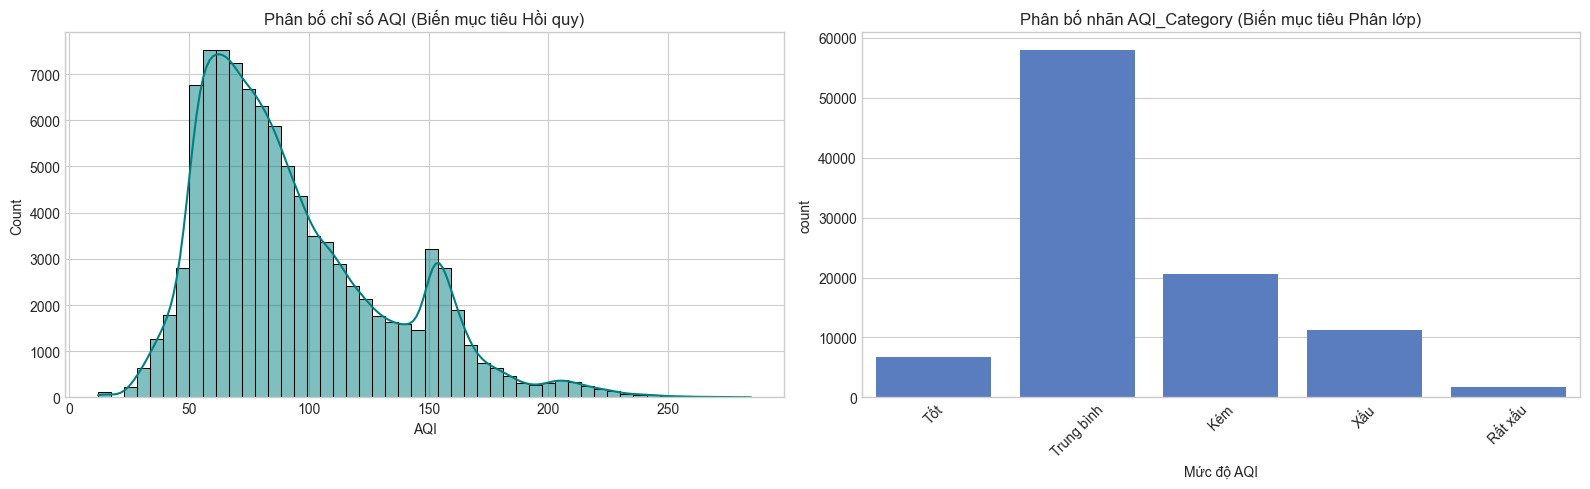

Tỷ lệ các lớp trong aqi_category:
aqi_category
Trung bình    59.06
Kém           20.97
Xấu           11.38
Tốt            6.79
Rất xấu        1.80
Name: proportion, dtype: float64


In [82]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# 1. Phân bố biến liên tục AQI
sns.histplot(df['aqi'], bins=50, kde=True, ax=ax[0], color='teal')
ax[0].set_title('Phân bố chỉ số AQI (Biến mục tiêu Hồi quy)')
ax[0].set_xlabel('AQI')

# 2. Phân bố các nhóm AQI Category
category_order = ["Tốt", "Trung bình", "Kém", "Xấu", "Rất xấu"]

sns.countplot(data=df, x='aqi_category', order=category_order, ax=ax[1])
ax[1].set_title('Phân bố nhãn AQI_Category (Biến mục tiêu Phân lớp)')
ax[1].set_xlabel('Mức độ AQI')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# In tỷ lệ phần trăm
print("Tỷ lệ các lớp trong aqi_category:")
print((df['aqi_category'].value_counts(normalize=True) * 100).round(2))

**Nhận xét về phân bổ dữ liệu:**

* **Biến mục tiêu AQI (Hồi quy):** 
    * Phân phối có xu hướng lệch phải. Phần lớn các giá trị tập trung ở dải từ 50 đến 150. Các giá trị cực cao (>200) xuất hiện với tần suất thấp hơn nhưng tạo ra "đuôi" dài, đại diện cho những thời điểm ô nhiễm nghiêm trọng.
* **Biến phân loại AQI_Category (Phân loại):**
    * Dữ liệu đang gặp tình trạng **mất cân bằng (Class Imbalance) nghiêm trọng**. 
    * Nhóm **"Trung bình"** chiếm tỉ trọng lớn nhất (hơn 59%), trong khi nhóm **"Rất xấu"** chỉ chiếm tỉ lệ rất nhỏ (~1.8%).
    * **Hệ quả:** Nếu không xử lý, mô hình học máy sẽ có xu hướng dự đoán thiên kiến (bias) về lớp "Trung bình" và dự báo kém chính xác ở các mức độ ô nhiễm nặng - vốn là những mức quan trọng nhất cần cảnh báo sức khỏe. 
    * **Giải pháp:** Nhóm sẽ cân nhắc sử dụng các kỹ thuật như  tạo mẫu ảo cho lớp thiểu số hoặc điều chỉnh **Class Weights** trong quá trình huấn luyện mô hình.


<a id='3-2'></a>
### 3.2 Phân tích tương quan & Đa cộng tuyến (Multicollinearity)

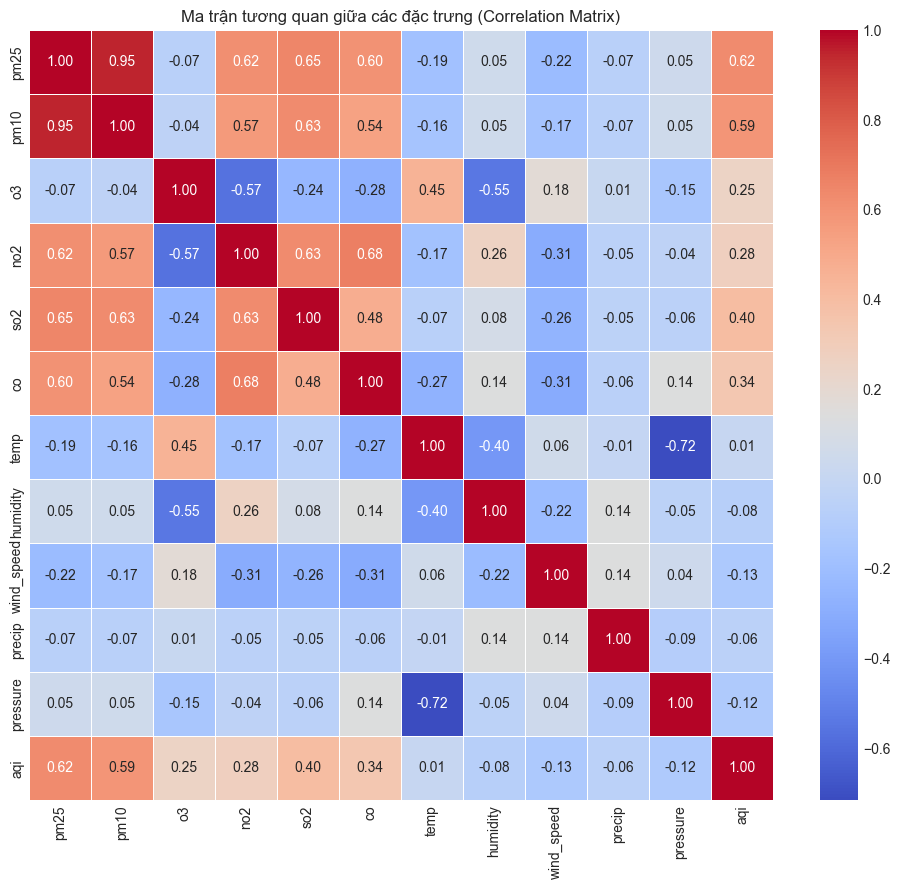

Tương quan với biến mục tiêu AQI:
pm25          0.624898
pm10          0.589058
so2           0.400327
co            0.339594
no2           0.276027
o3            0.250822
temp          0.007298
precip       -0.057784
humidity     -0.076147
pressure     -0.115387
wind_speed   -0.132125
Name: aqi, dtype: float64


In [83]:
plt.figure(figsize=(12, 10))
corr_cols = ['pm25', 'pm10', 'o3', 'no2', 'so2', 'co', 'temp', 'humidity', 'wind_speed', 'precip', 'pressure', 'aqi']
corr_matrix = df[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Ma trận tương quan giữa các đặc trưng (Correlation Matrix)")
plt.show()

# Trích xuất các biến có tương quan mạnh nhất với biến mục tiêu AQI
print("Tương quan với biến mục tiêu AQI:")
print(corr_matrix['aqi'].sort_values(ascending=False)[1:])

Dựa trên ma trận tương quan, nhóm tiến hành đánh giá mối quan hệ giữa các biến đầu vào và biến mục tiêu AQI:

* **Tương quan thuận mạnh:** Các biến nồng độ bụi mịn ($PM_{2.5}$, $PM_{10}$) và các chất khí ($NO_2$, $CO$, $SO2$) có tương quan thuận rất cao với AQI. Đặc biệt, $PM_{2.5}$ thường là yếu tố quyết định chính đến giá trị AQI tại Việt Nam.
* **Hiện tượng đa cộng tuyến:** Do $PM_{2.5}$ và $PM_{10}$ thường đi cùng nhau, chúng có thể gây ra hiện tượng đa cộng tuyến (correlation = 0.95). Việc phát hiện sớm điều này giúp nhóm quyết định có nên loại bỏ bớt đặc trưng hoặc sử dụng các mô hình có khả năng xử lý đa cộng tuyến tốt (như Ridge/Lasso Regression hoặc các mô hình dựa trên cây).
* **Yếu tố khí tượng:** Các biến như tốc độ gió và lượng mưa thường có tương quan nghịch với AQI (giúp phát tán bụi), trong khi độ ẩm và nhiệt độ có những tác động phức tạp hơn theo từng mùa.

<a id='3-3'></a>
### 3.3 Phát hiện ngoại lệ (Outliers)
Sử dụng Boxplot để kiểm tra các ngoại lệ của PM2.5 theo từng thành phố.

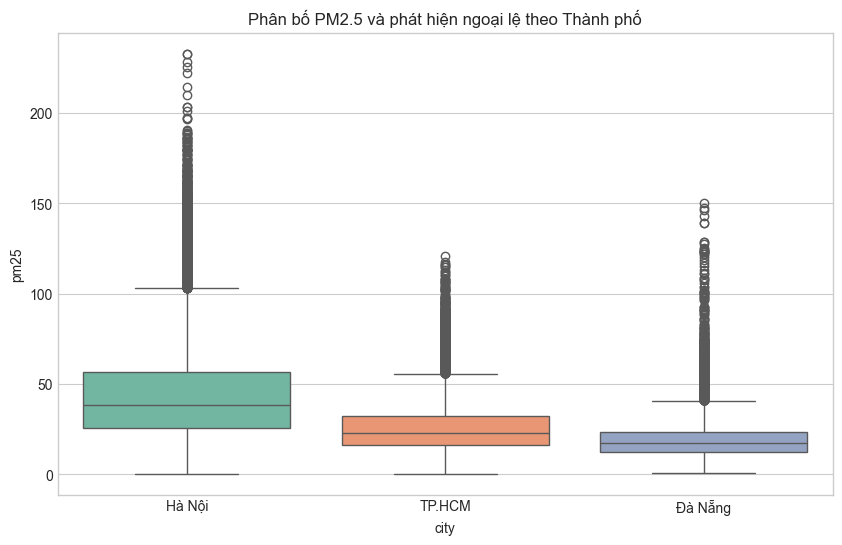

In [84]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='city', y='pm25', palette='Set2')
plt.title("Phân bố PM2.5 và phát hiện ngoại lệ theo Thành phố")
plt.show()

**Nhận xét:**
- **Hà Nội**: Nhiều outliers (100–230+) → ô nhiễm cực nặng, biến động lớn  
- **TP.HCM**: Ít hơn (~100–120) → có biến động nhưng nhẹ hơn  
- **Đà Nẵng**: Median thấp nhất, vẫn có spike (~140–150) → thường sạch nhưng có đột biến  

-> Outliers **không phải lỗi**, mà là các **đợt ô nhiễm bất thường**.

**Quyết định:**
- **Giữ lại outliers** vì phản ánh đúng thực tế môi trường các ngày ô nhiễm cực đoan và quan trọng cho phân tích và cảnh báo  
- Có thể **gắn nhãn** phục vụ training thay vì xóa.

<a id='4'></a>
## 4. Tiền xử lý dữ liệu cho Mô hình Học máy

<a id='4-1'></a>
### 4.1 Chuẩn hóa và Biến đổi kiểu dữ liệu
* **One-hot Encoding:** Cho biến `city`, `season`.
* **Label Encoding:** Cho biến mục tiêu phân loại `aqi_category` nếu dùng cho bài toán Classification.
* Loại bỏ biến `datetime` sau khi đã trích xuất xong các thuộc tính thời gian (year, month, hour,...).

In [85]:
# One-hot encode cho biến phân loại
df_encoded = pd.get_dummies(df, columns=['city', 'season'], drop_first=False)

# Chuyển đổi aqi_category sang dạng số
category_mapping = {'Good': 0, 'Moderate': 1, 'Unhealthy for Sensitive Groups': 2, 
                    'Unhealthy': 3, 'Very Unhealthy': 4, 'Hazardous': 5}
df_encoded['aqi_category_encoded'] = df_encoded['aqi_category'].map(category_mapping)

# Tách biến
features_to_drop = ['datetime', 'eu_aqi', 'aqi_category', 'aqi', 'aqi_category_encoded']
X = df_encoded.drop(columns=features_to_drop)

# Target 1 (Hồi quy)
y_reg = df_encoded['aqi']

# Target 2 (Phân loại)
y_clf = df_encoded['aqi_category_encoded']

<a id='4-2'></a>
### 4.2 Train/Val/Test Split (Time-Series)
Do bản chất là dữ liệu chuỗi thời gian, ta không nên sử dụng `train_test_split` ngẫu nhiên (sẽ gây rò rỉ dữ liệu từ tương lai về quá khứ). Dữ liệu sẽ được chia tuần tự theo thời gian:
* **Train:** 70% dữ liệu cũ nhất
* **Val:** 15% tiếp theo
* **Test:** 15% mới nhất

In [86]:
# Do dữ liệu đã được sort theo datetime trong quá trình tiền xử lý trước đó
n = len(X)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

X_train, y_train_reg, y_train_clf = X.iloc[:train_end], y_reg.iloc[:train_end], y_clf.iloc[:train_end]
X_val, y_val_reg, y_val_clf = X.iloc[train_end:val_end], y_reg.iloc[train_end:val_end], y_clf.iloc[train_end:val_end]
X_test, y_test_reg, y_test_clf = X.iloc[val_end:], y_reg.iloc[val_end:], y_clf.iloc[val_end:]

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Val: {X_val.shape}")
print(f"Kích thước tập Test: {X_test.shape}")

Kích thước tập Train: (68730, 37)
Kích thước tập Val: (14728, 37)
Kích thước tập Test: (14729, 37)


<a id='4-3'></a>
### 4.3 Chuẩn hóa dữ liệu (Scaling)
Áp dụng `StandardScaler` cho các biến liên tục. Chú ý chỉ fit trên tập Train để tránh rò rỉ dữ liệu.

In [87]:
from sklearn.preprocessing import StandardScaler

# Chỉ scale những cột numeric, bỏ qua các cột đã one-hot encoded
numeric_features = ['pm25', 'pm10', 'o3', 'no2', 'so2', 'co', 'temp', 'humidity', 
                    'wind_speed', 'precip', 'pressure', 'cloud_cover', 
                    'pm25_lag_1h', 'pm25_lag_3h', 'pm25_lag_6h', 'pm25_lag_12h', 'pm25_lag_24h', 
                    'pm25_roll_6h', 'pm25_roll_24h', 'pm25_roll_72h']

scaler = StandardScaler()

# Cần đảm bảo copy để không warning SettingWithCopy
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_val_scaled[numeric_features] = scaler.transform(X_val[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print("Đã hoàn tất quá trình chuẩn hóa. Dữ liệu sẵn sàng cho bước Xây dựng mô hình.")

Đã hoàn tất quá trình chuẩn hóa. Dữ liệu sẵn sàng cho bước Xây dựng mô hình.
